--- REGRESSIONS-ERGEBNISSE ---
Berechnete Rotationskonstante (Steigung): 5.1224
Bestimmtheitsmaß (R²-Wert): 0.9944


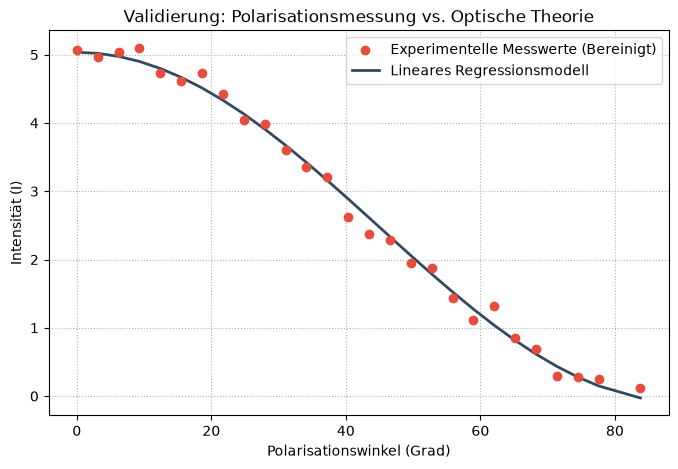

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. Data Engineering: Rohdaten-Simulation (Polarisationsmessungen)
np.random.seed(42)
winkel = np.linspace(0, 90, num=30)  # Polarisationswinkel in Grad

# Generar intensidades teóricas con ruido experimental térmico
intensitaet_theorie = 5.0 * (np.cos(np.radians(winkel))**2)
rauschen = np.random.normal(0, 0.15, size=30)
intensitaet_gemessen = intensitaet_theorie + rauschen

# Erstellung des DataFrames
df = pd.DataFrame({
    'winkel_grad': winkel,
    'intensitaet_messung': intensitaet_gemessen
})

# Bereinigung: Filterung von ungültigen/negativen Messwerten (Sensorfehler)
df = df[df['intensitaet_messung'] >= 0].reset_index(drop=True)

# 2. Modellierung: Lineare Regression für Rotationskonstanten
# Umwandlung für Linearisierung (Malus-Gesetz Anpassung)
x_linearisiert = np.cos(np.radians(df['winkel_grad']))**2
y_messung = df['intensitaet_messung']

steigung, achsenabschnitt, r_value, p_value, std_err = linregress(x_linearisiert, y_messung)

print(f"--- REGRESSIONS-ERGEBNISSE ---")
print(f"Berechnete Rotationskonstante (Steigung): {steigung:.4f}")
print(f"Bestimmtheitsmaß (R²-Wert): {r_value**2:.4f}")

# 3. Visual Analytics: Automatisierter Abgleich (Theorie vs. Experiment)
plt.figure(figsize=(8, 5))
plt.scatter(df['winkel_grad'], df['intensitaet_messung'], color='#e74c3c', label='Experimentelle Messwerte (Bereinigt)', zorder=3)
plt.plot(df['winkel_grad'], achsenabschnitt + steigung * (np.cos(np.radians(df['winkel_grad']))**2), color='#34495e', lw=2, label='Lineares Regressionsmodell')
plt.title('Validierung: Polarisationsmessung vs. Optische Theorie')
plt.xlabel('Polarisationswinkel (Grad)')
plt.ylabel('Intensität (I)')
plt.legend()
plt.grid(True, linestyle=':')
plt.savefig('optical_validation_plot.png')
plt.show()